In [1]:
import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import os
from matplotlib import rcParams
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sc.settings.n_jobs = 20

In [3]:
rcParams["figure.figsize"] = (5, 5)

import warnings

warnings.simplefilter("ignore", category=UserWarning)

In [4]:
rna = sc.read('/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/mosaic_integration_scglue/rna-pp-2k-hvg.h5ad')
rna

AnnData object with n_obs × n_vars = 397794 × 19248
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_RAW', 'nFeature_RAW', 'DF.class', 'DF.score', 'scDblFinder.class', 'scDblFinder.score', 'ID', 'SampleID', 'Data', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'nFeature_Diff', 'nCount_Diff', 'Batch_for_correction', 'scDblFinder.clusters.class', 'scDblFinder.clusters.score', 'scDblFinder.class.clusters', 'doublet.combn.fisher', 'doublet.combn.mean', 'doublet.combn.fisher.class', 'doublet.combn.mean.class', 'Study', 'Original_annotation', 'Isolation_method_by_cell', 'Cell_type_granular_mouse_correlations', 'Cell_type_mouse_correlations', 'Cell_type_consensus_Jessa2022', 'Malignant_normal_consensus_Jessa2022', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sampl

In [5]:
emb = sc.read(os.path.join('/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/mosaic_integration_scglue', "myeloid_embbeding.h5ad"))
emb

AnnData object with n_obs × n_vars = 74891 × 0
    obs: 'scDblFinder.class', 'scDblFinder.score', 'ID', 'SampleID', 'Batch_for_correction', 'Study', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sample', 'Multisector', 'Gender', 'Age_years', 'Dexamethasone_prior_surgery', 'Survival', 'Survival_months', 'Mitosis', 'Ki67', 'Methylation_array', 'H3F3A', 'H3C3', 'HIST1H3B', 'HIST2H3C', 'TP53', 'EGFR', 'PDGFRA', 'SUFU', 'NF1', 'pTERT', 'PIK3CA', 'PIK3R1', 'ATRX', 'PTEN', 'ASXL1', 'BCOR', 'BCORL1', 'SMC1A', 'WT1', 'PPM1D', 'ACVR1', 'TSHR', 'BRAF', 'GNAQ', 'LMNA', 'KIT', 'ARID1A', 'KRAS', 'Other', 'cell_id', 'modality', 'domain', 'leiden_1', 'leiden_1_3', 'leiden_1_5', 'leiden_1_8', 'leiden_2', 'leiden_2_3', 'leiden_2_5', 'leiden_2_8', 'leiden_3', 'louvain_1', 'louvain_1_3', 'louvain_1_5',

In [6]:
obs_columns = ['modality', 'leiden_1', 'leiden_1_3', 'leiden_1_5',
               'leiden_1_8', 'leiden_2', 'leiden_2_3', 'leiden_2_5', 
               'leiden_2_8', 'leiden_3', 'louvain_1', 'louvain_1_3', 
               'louvain_1_5', 'louvain_1_8', 'louvain_2', 'louvain_2_3',
               'louvain_2_5', 'louvain_2_8', 'louvain_3', 'iCNV']

obsm_keys = ['X_glue', 'X_umap']

def transfer_data(from_obj, to_obj):
    
    for col in obs_columns:
        if col in from_obj.obs:
            to_obj.obs[col] = from_obj.obs[col].reindex(to_obj.obs_names).values
        else:
            print(f"Column {col} not found in 'from_obj.obs'. Skipping.")
    
    for key in obsm_keys:
        if key in from_obj.obsm.keys():
            mask = from_obj.obs_names.isin(to_obj.obs_names)
            to_obj.obsm[key] = from_obj.obsm[key][mask, :]
        else:
            print(f"Key {key} not found in 'from_obj.obsm'. Skipping.")

In [7]:
cells_to_keep_rna = emb[emb.obs['domain'].isin(['scRNA-seq'])].obs_names
rna = rna[rna.obs_names.isin(cells_to_keep_rna), :].copy()
rna

AnnData object with n_obs × n_vars = 60672 × 19248
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_RAW', 'nFeature_RAW', 'DF.class', 'DF.score', 'scDblFinder.class', 'scDblFinder.score', 'ID', 'SampleID', 'Data', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'nFeature_Diff', 'nCount_Diff', 'Batch_for_correction', 'scDblFinder.clusters.class', 'scDblFinder.clusters.score', 'scDblFinder.class.clusters', 'doublet.combn.fisher', 'doublet.combn.mean', 'doublet.combn.fisher.class', 'doublet.combn.mean.class', 'Study', 'Original_annotation', 'Isolation_method_by_cell', 'Cell_type_granular_mouse_correlations', 'Cell_type_mouse_correlations', 'Cell_type_consensus_Jessa2022', 'Malignant_normal_consensus_Jessa2022', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sample

In [8]:
emb_rna =  emb[emb.obs['domain'].isin(['scRNA-seq'])]
emb_rna

View of AnnData object with n_obs × n_vars = 60672 × 0
    obs: 'scDblFinder.class', 'scDblFinder.score', 'ID', 'SampleID', 'Batch_for_correction', 'Study', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sample', 'Multisector', 'Gender', 'Age_years', 'Dexamethasone_prior_surgery', 'Survival', 'Survival_months', 'Mitosis', 'Ki67', 'Methylation_array', 'H3F3A', 'H3C3', 'HIST1H3B', 'HIST2H3C', 'TP53', 'EGFR', 'PDGFRA', 'SUFU', 'NF1', 'pTERT', 'PIK3CA', 'PIK3R1', 'ATRX', 'PTEN', 'ASXL1', 'BCOR', 'BCORL1', 'SMC1A', 'WT1', 'PPM1D', 'ACVR1', 'TSHR', 'BRAF', 'GNAQ', 'LMNA', 'KIT', 'ARID1A', 'KRAS', 'Other', 'cell_id', 'modality', 'domain', 'leiden_1', 'leiden_1_3', 'leiden_1_5', 'leiden_1_8', 'leiden_2', 'leiden_2_3', 'leiden_2_5', 'leiden_2_8', 'leiden_3', 'louvain_1', 'louvain_1_3', 'louva

In [9]:
transfer_data(emb_rna, rna)
rna

AnnData object with n_obs × n_vars = 60672 × 19248
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_RAW', 'nFeature_RAW', 'DF.class', 'DF.score', 'scDblFinder.class', 'scDblFinder.score', 'ID', 'SampleID', 'Data', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'nFeature_Diff', 'nCount_Diff', 'Batch_for_correction', 'scDblFinder.clusters.class', 'scDblFinder.clusters.score', 'scDblFinder.class.clusters', 'doublet.combn.fisher', 'doublet.combn.mean', 'doublet.combn.fisher.class', 'doublet.combn.mean.class', 'Study', 'Original_annotation', 'Isolation_method_by_cell', 'Cell_type_granular_mouse_correlations', 'Cell_type_mouse_correlations', 'Cell_type_consensus_Jessa2022', 'Malignant_normal_consensus_Jessa2022', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sample

In [10]:
nmf_meta = pd.read_csv('data/nmf_assigment_myeloid_no_core_programs.csv', 
                       sep=',', index_col=0)
nmf_meta

/scratch-local/cruiz2.11982906/ipykernel_3945786/2939786245.py:1: DtypeWarning: Columns (27,29,30,31,32,33,34,39,40,49,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86) have mixed types. Specify dtype option on import or set low_memory=False.
  nmf_meta = pd.read_csv('data/nmf_assigment_myeloid_no_core_programs.csv',


,nCount_RNA,nFeature_RNA,nCount_RAW,nFeature_RAW,DF.class,DF.score,scDblFinder.class,scDblFinder.score,ID,SampleID,...,iCNV,cell_id,MP_4_1,MP_10_1,MP_7_1,MP_2_1,MP_8_1,MP_9_1,MP_Assignment,Material
BT042_PD_TGCGATAAGCCATCCG-1,4960,2065,4994,2080,Singlet,0.109091,Singlet,0.769243,T18-90532,BT042_PD,...,normal,TAM_BDM,-0.002364,-0.130576,0.064429,0.034152,0.114909,-0.072766,MP8,nuclei
BT042_PD_GAATAGAGTTTATGCG-1,4726,2219,4867,2231,Singlet,0.072727,Singlet,0.246590,T18-90532,BT042_PD,...,normal,TAM_BDM,0.039986,-0.178076,-0.073085,0.186855,0.260973,-0.085841,MP8,nuclei
BT042_PD_CCTGCATAGGTCACAG-1,4652,1813,4668,1824,Singlet,0.127273,Singlet,0.089384,T18-90532,BT042_PD,...,normal,TAM_BDM,-0.142082,-0.221548,0.115024,-0.458207,0.165746,0.105210,MP8,nuclei
BT042_PD_CGGAGAACAACTGCTA-1,4820,2178,4903,2192,Singlet,0.145455,Doublet,0.995484,T18-90532,BT042_PD,...,normal,TAM_BDM,0.028380,-0.066346,0.010895,-0.154446,0.384569,-0.042155,MP8,nuclei
BT042_PD_AGGGCTCCAACTCGTA-1,4537,1881,4567,1899,Singlet,0.090909,Singlet,0.477385,T18-90532,BT042_PD,...,normal,TAM_BDM,0.215260,-0.063445,-0.028994,-0.267972,0.170351,-0.073958,MP4,nuclei
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
multiome_P-6774_S-10146_GAGTGATCAAGTGTTT-1,302,242,525,441,Singlet,0.152426,Singlet,0.000042,P-6774_S-10146,P-6774_S-10146_Multiome,...,normal,TAM_MG,-0.061626,-0.114051,0.120934,-0.116285,-0.051570,0.090315,MP9,nuclei
multiome_P-6774_S-10146_GGTCAGGAGTGCTGTG-1,342,251,506,396,Singlet,0.180335,Singlet,0.000043,P-6774_S-10146,P-6774_S-10146_Multiome,...,normal,B_cell,-0.053194,-0.110151,0.092189,-0.111155,0.001728,0.231313,MP9,nuclei
multiome_P-6774_S-10146_TGGATTCAGACAAGTG-1,302,226,461,366,Singlet,0.142980,Singlet,0.000059,P-6774_S-10146,P-6774_S-10146_Multiome,...,normal,TAM_MG,-0.057900,-0.168168,0.022438,-0.166866,0.005623,0.280707,MP9,nuclei
multiome_P-6774_S-10146_TCCAGGTCAATTGAAG-1,283,221,447,362,Singlet,0.155861,Singlet,0.000023,P-6774_S-10146,P-6774_S-10146_Multiome,...,normal,TAM_BDM,0.004575,-0.103951,0.007905,0.013948,0.087544,0.064315,MP8,nuclei


In [11]:
adata = rna

In [12]:
adata.obs['nmf'] = nmf_meta['MP_Assignment'].loc[adata.obs.index]

In [14]:
adata_subset = adata[~adata.obs['nmf'].isin(['unresolved'])].copy() 
adata_subset

AnnData object with n_obs × n_vars = 59217 × 19248
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_RAW', 'nFeature_RAW', 'DF.class', 'DF.score', 'scDblFinder.class', 'scDblFinder.score', 'ID', 'SampleID', 'Data', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'nFeature_Diff', 'nCount_Diff', 'Batch_for_correction', 'scDblFinder.clusters.class', 'scDblFinder.clusters.score', 'scDblFinder.class.clusters', 'doublet.combn.fisher', 'doublet.combn.mean', 'doublet.combn.fisher.class', 'doublet.combn.mean.class', 'Study', 'Original_annotation', 'Isolation_method_by_cell', 'Cell_type_granular_mouse_correlations', 'Cell_type_mouse_correlations', 'Cell_type_consensus_Jessa2022', 'Malignant_normal_consensus_Jessa2022', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sample

In [ ]:
import pandas as pd

# Ensure 'MP_Assignment' is categorical
adata_subset.obs['nmf'] = adata_subset.obs['nmf'].astype(pd.CategoricalDtype(categories=['MP4','MP10','MP7','MP2','MP8','MP9'], 
                                                                                                ordered=True))

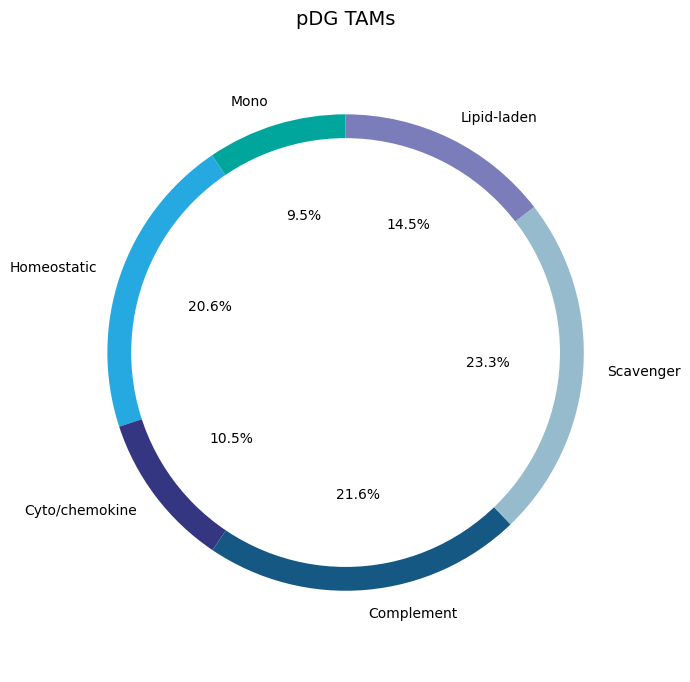

In [44]:
import matplotlib.pyplot as plt

# Step 1: Rename categories
rename_map = {
    'MP4': 'Mono',
    'MP10': 'Homeostatic',
    'MP7': 'Cyto/chemokine',
    'MP2': 'Complement',
    'MP8': 'Scavenger',
    'MP9': 'Lipid-laden'
}
adata_subset.obs['nmf_renamed'] = adata_subset.obs['nmf'].map(rename_map)

# Step 2: Define the order and colors
category_order = ['Mono', 'Homeostatic', 'Cyto/chemokine', 'Complement', 'Scavenger', 'Lipid-laden']
colors = ['#00a69c', '#26a9e0', '#343682', '#165884', '#95bbcd', '#7b7dba']

# Step 3: Get value counts in correct order
counts = adata_subset.obs['nmf_renamed'].value_counts()
counts = counts.reindex(category_order)

# Step 4: Plot
fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    counts,
    labels=counts.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.3)
)

# Add white circle for donut effect
centre_circle = plt.Circle((0, 0), 0.9, fc='white')
ax.add_artist(centre_circle)

ax.axis('equal')
plt.title("pDG TAMs", fontsize=14)
plt.tight_layout()
plt.savefig('figures/donut_plot_TAMs.pdf')
plt.show()

In [19]:
from scanpy.tl import score_genes

# BDM
score_genes(adata_subset, gene_list=['CTSD','F13A1', 'TGFBI', 'ITGA4', 'CD163', 'MRC1', 'SELENOP','GPNMB', 'LGALS3'], score_name='BDM_score')
# MG
mg_list = ['CTSD', 'F13A1', 'TGFBI', 'ITGA4', 'CD163', 'MRC1', 'SELENOP', 'GPNMB', 'LGALS3', 'ANKUB1', 'SLC35G2', 'ATP8B1', 'FAM177B', 'P2RY13', 'PLAT', 'PTPRB', 'SHOC1', 'C11ORF65', 'MCF2L2', 'OPRM1', 'TEX14', 'TRIM13', 'ZFP36L2', 'CLEC7A', 'CP', 'EYS', 'INKA2', 'MGLL', 'PAQR3', 'RAB11A', 'APOC2', 'CPVL', 'CX3CR1', 'FOS', 'IER3', 'SERPINB9', 'SPATA1', 'TMIGD3', 'TRIM5', 'ABI2', 'CCDC168', 'CGGBP1', 'DLEU7', 'FILIP1L', 'FTL', 'H3F3B', 'IER2', 'INSYN2B', 'JUNB', 'MAPK10', 'MED12L', 'RDX', 'BIN1', 'CCDC97', 'GPR34', 'ZFP36L1', 'CD4', 'USP53', 'ENO4']
score_genes(adata_subset, gene_list=mg_list, score_name='MG_score')

# 2. Prepare your categories and counts as before
category_order = ['Mono', 'Homeostatic', 'Cyto/chemokine', 'Complement', 'Scavenger', 'Lipid-laden']
colors = ['#00a69c', '#26a9e0', '#343682', '#165884', '#95bbcd', '#7b7dba']

# 3. For each category, get the list of scores for BDM and MG
score_data = []
for cat in category_order:
    cells = adata_subset.obs['nmf_renamed'] == cat
    bdm_scores = adata_subset.obs.loc[cells, 'BDM_score']
    mg_scores = adata_subset.obs.loc[cells, 'MG_score']
    score_data.append({
        'category': cat,
        'bdm_scores': bdm_scores,
        'mg_scores': mg_scores,
        'count': sum(cells)
    })

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Make sure nmf_renamed, BDM_score, and MG_score columns exist in adata_subset.obs
category_order = ['Mono', 'Homeostatic', 'Cyto/chemokine', 'Complement', 'Scavenger', 'Lipid-laden']
colors = ['#00a69c', '#26a9e0', '#343682', '#165884', '#95bbcd', '#7b7dba']  # for cell type plot

# Mean scores per category
means_bdm = adata_subset.obs.groupby('nmf_renamed')['BDM_score'].mean().reindex(category_order)
means_mg = adata_subset.obs.groupby('nmf_renamed')['MG_score'].mean().reindex(category_order)

# For cell type counts
counts = adata_subset.obs['nmf_renamed'].value_counts().reindex(category_order)

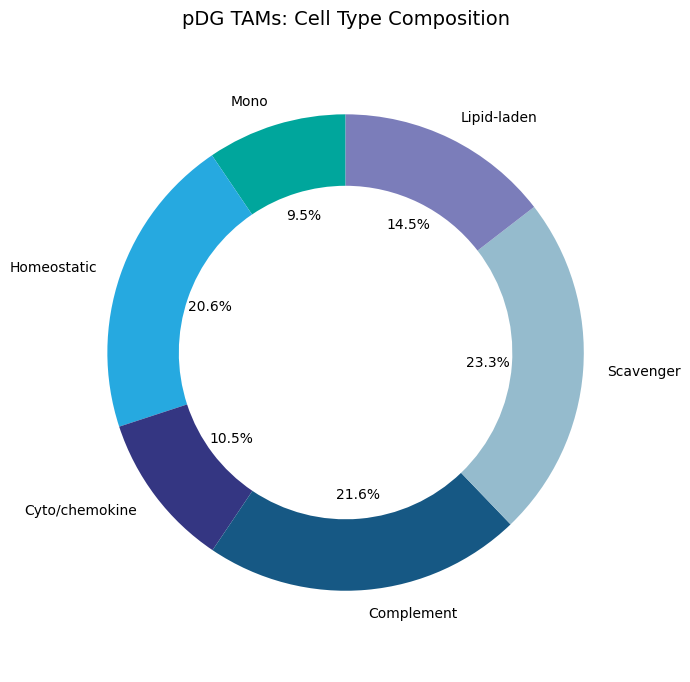

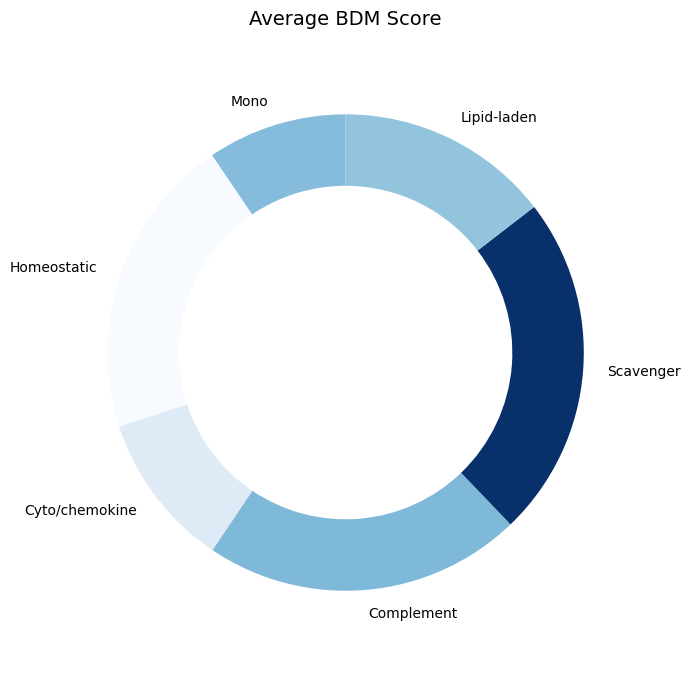

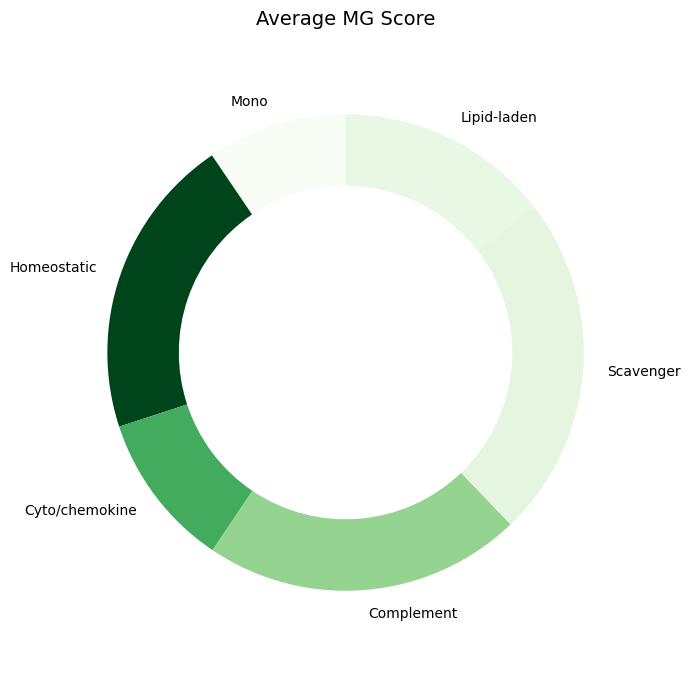

In [23]:
# Donut 1: Cell type composition
fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    counts,
    labels=counts.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.3)
)
centre_circle = plt.Circle((0, 0), 0.5, fc='white')
ax.add_artist(centre_circle)
ax.axis('equal')
plt.title("pDG TAMs: Cell Type Composition", fontsize=14)
plt.tight_layout()
plt.show()

# Donut 2: Average BDM score per cell type (colormap, same order)
fig, ax = plt.subplots(figsize=(7, 7))
# Normalize to [0,1] for colormap
norm = plt.Normalize(means_bdm.min(), means_bdm.max())
cmap = cm.Blues
bdm_colors = [cmap(norm(val)) for val in means_bdm]
wedges, texts = ax.pie(
    counts,
    labels=counts.index,
    colors=bdm_colors,
    startangle=90,
    wedgeprops=dict(width=0.3)
)
centre_circle = plt.Circle((0, 0), 0.5, fc='white')
ax.add_artist(centre_circle)
ax.axis('equal')
plt.title("Average BDM Score", fontsize=14)
plt.tight_layout()
plt.show()

# Donut 3: Average MG score per cell type (colormap, same order)
fig, ax = plt.subplots(figsize=(7, 7))
norm = plt.Normalize(means_mg.min(), means_mg.max())
cmap = cm.Greens
mg_colors = [cmap(norm(val)) for val in means_mg]
wedges, texts = ax.pie(
    counts,
    labels=counts.index,
    colors=mg_colors,
    startangle=90,
    wedgeprops=dict(width=0.3)
)
centre_circle = plt.Circle((0, 0), 0.5, fc='white')
ax.add_artist(centre_circle)
ax.axis('equal')
plt.title("Average MG Score", fontsize=14)
plt.tight_layout()
plt.show()

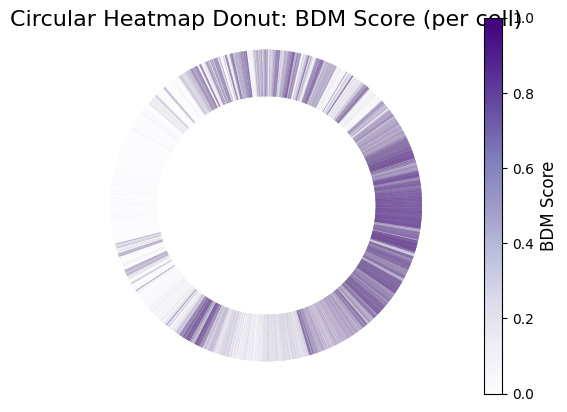

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

category_order = ['Mono', 'Homeostatic', 'Cyto/chemokine', 'Complement', 'Scavenger', 'Lipid-laden']
donut_width = 0.3
inner_radius = 0.5

cell_types = adata_subset.obs['nmf_renamed']
bdm_scores = adata_subset.obs['BDM_score']

# Sort cells by category_order
sorted_indices = np.concatenate([
    np.where(cell_types == cat)[0] for cat in category_order
])
bdm_scores_sorted = bdm_scores.iloc[sorted_indices].values
cell_types_sorted = cell_types.iloc[sorted_indices].values

n_cells = len(bdm_scores_sorted)
counts_per_cat = [(cell_types_sorted == cat).sum() for cat in category_order]
theta_per_cell = 360 / n_cells

# ---- Set vmin and vmax here ----
vmin = 0        
vmax = 1       
norm = plt.Normalize(vmin, vmax)

cmap = cm.Purples
cell_colors = [cmap(norm(val)) for val in bdm_scores_sorted]

fig, ax = plt.subplots(figsize=(5,5), subplot_kw={'aspect':'equal'})
start_angle = 90
angle = start_angle

for count in counts_per_cat:
    for i in range(count):
        theta1 = angle
        theta2 = angle + theta_per_cell
        wedge = plt.matplotlib.patches.Wedge(center=(0,0),
                                             r=1.0,
                                             theta1=theta1,
                                             theta2=theta2,
                                             width=donut_width,
                                             facecolor=cell_colors[0],
                                             edgecolor=None,
                                             lw=0)
        ax.add_patch(wedge)
        cell_colors.pop(0)
        angle += theta_per_cell

centre_circle = plt.Circle((0, 0), inner_radius, fc='white')
ax.add_artist(centre_circle)
ax.set_xlim(-1.1,1.1)
ax.set_ylim(-1.1,1.1)
ax.axis('off')
plt.title("Circular Heatmap Donut: BDM Score (per cell)", fontsize=16)

# ---- Add colorbar legend ----
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Needed for matplotlib < 3.1
cbar = plt.colorbar(sm, ax=ax, pad=0.1, shrink=0.8)
cbar.set_label('BDM Score', fontsize=12)

plt.tight_layout()
plt.savefig('figures/donut_plot_BDM_scores.pdf')
plt.show()

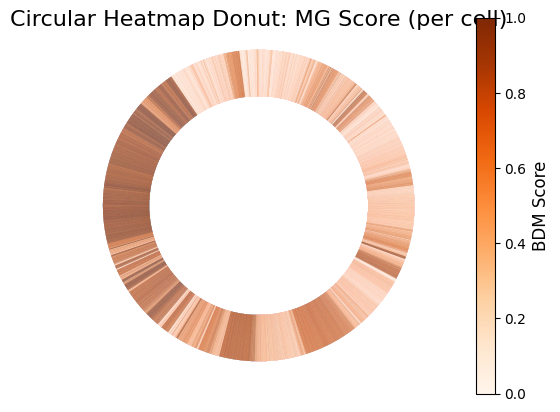

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

category_order = ['Mono', 'Homeostatic', 'Cyto/chemokine', 'Complement', 'Scavenger', 'Lipid-laden']
donut_width = 0.3
inner_radius = 0.5

cell_types = adata_subset.obs['nmf_renamed']
mg_scores = adata_subset.obs['MG_score']

# Sort cells by category_order
sorted_indices = np.concatenate([
    np.where(cell_types == cat)[0] for cat in category_order
])
mg_scores_sorted = mg_scores.iloc[sorted_indices].values
cell_types_sorted = cell_types.iloc[sorted_indices].values

n_cells = len(mg_scores_sorted)
counts_per_cat = [(cell_types_sorted == cat).sum() for cat in category_order]
theta_per_cell = 360 / n_cells

# ---- Set vmin and vmax here ----
vmin = 0        
vmax = 1       
norm = plt.Normalize(vmin, vmax)

cmap = cm.Oranges
cell_colors = [cmap(norm(val)) for val in mg_scores_sorted]

fig, ax = plt.subplots(figsize=(5,5), subplot_kw={'aspect':'equal'})
start_angle = 90
angle = start_angle

for count in counts_per_cat:
    for i in range(count):
        theta1 = angle
        theta2 = angle + theta_per_cell
        wedge = plt.matplotlib.patches.Wedge(center=(0,0),
                                             r=1.0,
                                             theta1=theta1,
                                             theta2=theta2,
                                             width=donut_width,
                                             facecolor=cell_colors[0],
                                             edgecolor=None,
                                             lw=0)
        ax.add_patch(wedge)
        cell_colors.pop(0)
        angle += theta_per_cell

centre_circle = plt.Circle((0, 0), inner_radius, fc='white')
ax.add_artist(centre_circle)
ax.set_xlim(-1.1,1.1)
ax.set_ylim(-1.1,1.1)
ax.axis('off')
plt.title("Circular Heatmap Donut: MG Score (per cell)", fontsize=16)

# ---- Add colorbar legend ----
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Needed for matplotlib < 3.1
cbar = plt.colorbar(sm, ax=ax, pad=0.1, shrink=0.8)
cbar.set_label('BDM Score', fontsize=12)

plt.tight_layout()
plt.savefig('figures/donut_plot_MG_scores.pdf')
plt.show()